### Imports Sys


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader      import load_all
from src.data.cleaner     import clean_medals, clean_countries
from src.features.builder import build_features, get_feature_cols
from src.features.selector import select_top_k

### Load and clean


In [2]:
medals_raw, countries_raw = load_all(config_path='../config/config.yaml')
medals    = clean_medals(medals_raw)
countries = clean_countries(countries_raw)
print('Medals:', medals.shape)
print('Countries:', countries.shape)

✅ Medals loaded: (36935, 12) | Countries: (201, 5)
   Summer records : 31,165
   Winter records : 5,770
   Project root used: C:\Users\ACER\OneDrive\Desktop\Bull\Olympics-ML-Analysis
Medals: (31512, 12)
Countries: (201, 5)


### Build features

In [3]:
features = build_features(medals, countries)
print('Features shape:', features.shape)
features.head()

Features shape: (1447, 14)


,Country,Year,Season,TotalMedals,GoldMedals,SilverMedals,BronzeMedals,WeightedScore,PrevMedals,RollingMean3,MedalDelta,IsSummer,Population,GDP per Capita
0,AUS,1994,Winter,4,0,0,4,4,0.0,0.000000,4.0,0,23344179.0,19222.150076
1,AUS,1998,Winter,1,0,0,1,1,4.0,4.000000,-3.0,0,23344179.0,19222.150076
2,AUS,2002,Winter,2,2,0,0,6,1.0,2.500000,1.0,0,23344179.0,19222.150076
3,AUS,2006,Winter,2,1,0,1,4,2.0,2.333333,0.0,0,23344179.0,19222.150076
4,AUS,2010,Winter,3,2,1,0,8,2.0,1.666667,1.0,0,23344179.0,19222.150076


### Feature columns


In [4]:
feat_cols = get_feature_cols(features)
print('Feature columns used for ML:')
print(feat_cols)

Feature columns used for ML:
['PrevMedals', 'RollingMean3', 'MedalDelta', 'IsSummer', 'Population', 'GDP per Capita']


### Check nulls in features


In [5]:
print('Nulls in feature columns:')
print(features[feat_cols].isnull().sum())

Nulls in feature columns:
PrevMedals        0
RollingMean3      0
MedalDelta        0
IsSummer          0
Population        0
GDP per Capita    0
dtype: int64


### Drop nulls


In [6]:
features = features.dropna()
print('Shape after dropping nulls:', features.shape)

Shape after dropping nulls: (1447, 14)


### Feature statistics


In [7]:
features[feat_cols].describe()

,PrevMedals,RollingMean3,MedalDelta,IsSummer,Population,GDP per Capita
count,1447.000000,1447.000000,1447.000000,1447.000000,1.447000e+03,1447.000000
mean,19.780926,18.726215,1.996545,0.738079,6.224001e+07,24170.317213
std,36.538196,31.536764,27.011024,0.439832,1.772870e+08,18505.368511
min,0.000000,0.000000,-331.000000,0.000000,6.523500e+04,277.068309
25%,2.000000,2.000000,-3.000000,0.000000,9.798871e+06,12363.543460
50%,6.000000,7.000000,1.000000,1.000000,2.334418e+07,19222.150076
75%,22.000000,21.000000,5.500000,1.000000,4.605030e+07,36205.568102
max,394.000000,275.666667,345.000000,1.000000,1.371220e+09,101449.968168


### Correlation heatmap


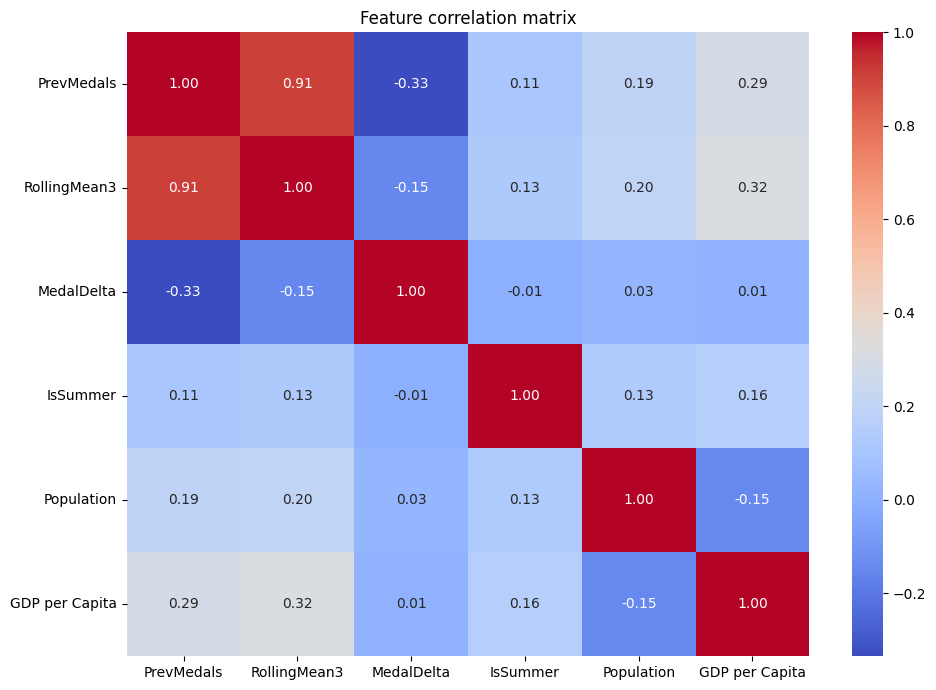

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(features[feat_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

### TotalMedals distribution


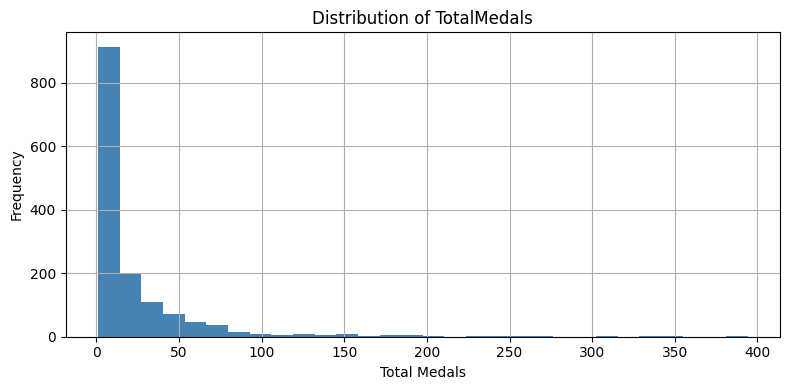

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
features['TotalMedals'].hist(bins=30, ax=ax, color='steelblue')
ax.set_title('Distribution of TotalMedals')
ax.set_xlabel('Total Medals')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### WeightedScore vs TotalMedals


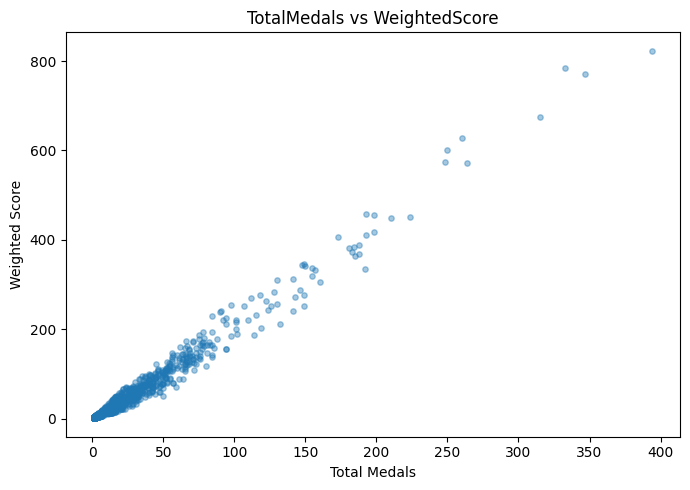

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(features['TotalMedals'], features['WeightedScore'], alpha=0.4, s=15)
ax.set_xlabel('Total Medals')
ax.set_ylabel('Weighted Score')
ax.set_title('TotalMedals vs WeightedScore')
plt.tight_layout()
plt.show()

### PrevMedals vs TotalMedals


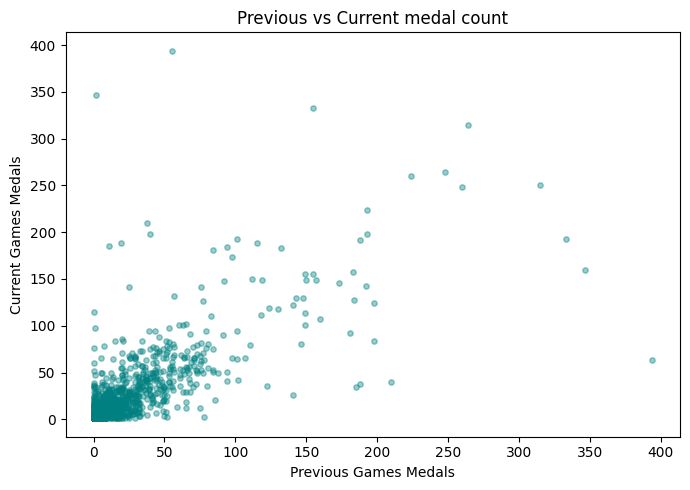

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(features['PrevMedals'], features['TotalMedals'], alpha=0.4, s=15, color='teal')
ax.set_xlabel('Previous Games Medals')
ax.set_ylabel('Current Games Medals')
ax.set_title('Previous vs Current medal count')
plt.tight_layout()
plt.show()

### Select top features


In [12]:
X = features[feat_cols].values
y = features['TotalMedals'].values
X_selected, selected_cols, selector = select_top_k(X, y, feat_cols, k=8)
print('Top selected features:', selected_cols)

Selected features: ['PrevMedals', 'RollingMean3', 'MedalDelta', 'IsSummer', 'Population', 'GDP per Capita']
Top selected features: ['PrevMedals', 'RollingMean3', 'MedalDelta', 'IsSummer', 'Population', 'GDP per Capita']


### Save features

In [13]:
features.to_csv('../data/processed/features.csv', index=False)
print('Features saved to data/processed/features.csv')

Features saved to data/processed/features.csv
